In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal


import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

from processors import temparature, season, month
from transforming import (
    Apply, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


df = pd.read_csv('data/train.csv', index_col='id')
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [6]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
MONTHS = [f'ct_month_{n}' for n in range(12)]
SEASONS = [f'ct_season_{n}' for n in range(4)]
ONE_HOTS = [*MONTHS, *SEASONS]


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
        Select(TEMPERATURES, mode='drop'),
    ),
    Select(TEMPERATURES, mode='drop'),
    # abs dewpoint
    Calc('abs(dewpoint)', to='dewpoint'),
    # some simple features
    Calc('_maxtemp - _mintemp', 'tempdelta'),
    Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('windspeed * winddirection', to='windspeed_mul_winddirection'),
    Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),
    Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='weather_index'),
    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='weather_index'),

    # Calc('', to=''),
    Fill(0),

    # calc month one hots
    Calc(month, to='ct_month'),
    # WithSelected(['ct_month'])(
    #     pre.OneHotEncoder(),
    # ),
    # calc seasons one hots
    # Calc(season, to='ct_season'),
    # WithSelected(['ct_season'])(
    #     pre.OneHotEncoder(),
    # ),

    # groupings
    # day-to-day statistic
    WithSelected(r'(?!ct_month|ct_season).*')(
        Group('day', 'mean', prefix='_day_mean_', include_target=True),
    ),
    # month-to-month statistic
    WithSelected(r'(?!day|ct_season|.*rainfall).*')(
        Group('ct_month', 'mean', prefix='_month_mean_', include_target=False),
    ),
    # # statistic by season
    # WithSelected(r'(?!day|ct_month_).*')(
    #     Group('ct_season', 'mean', prefix='season_mean_'),
    # ),

    # clusterize
    WithSelected(lambda name: name not in TEMPERATURES)(
        Fill('mean'),
        Apply(
            estimator=KMeans(n_clusters=3, random_state=17),
            locpipe=pre.StandardScaler(),
            to='ct_kmeans_cluster',
        ),
        Select(['kmeans_cluster'], mode='keep'),
    ),

    # add mean for last 3 days
    WithSelected(['pressure', 'humidity', 'cloud', 'sunshine'], prefix='last_3days_mean_')(
        Lag(3, 'mean'),
    ),
    # add for last day
    # WithSelected(['pressure', 'humidity', 'cloud', 'sunshine'], prefix='last_1days_mean_')(
    #     Lag(1, 'mean'),
    # ),
    # drop origin columns
    Select(ORIGIN, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
)
sgd_pipe = (
    *base_pipe,
    WithSelected(r'(?!ct|day).*$')(
        KeepDataframe(pre.StandardScaler()),
    )
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,_mintemp,_maxtemp,_temparature,tempdelta,sunshine_div_temparature,windspeed_mul_winddirection,cloud_mul_windspeed,humidity_mul_cloud,humidity_mul_sunshine,cloud_div_sunshine,...,_month_mean__day_mean_cloud_mul_windspeed,_month_mean__day_mean_humidity_mul_cloud,_month_mean__day_mean_humidity_mul_sunshine,_month_mean__day_mean_cloud_div_sunshine,_month_mean__day_mean_sunshine_rate,_month_mean__day_mean_weather_index,last_3days_mean_pressure,last_3days_mean_humidity,last_3days_mean_cloud,last_3days_mean_sunshine
id,,,,,,,,,,,,,,,,,,,,,
0,-0.448184,-0.916756,-0.640635,-1.924540,-0.629679,-0.598201,-0.184904,0.750543,-0.715426,-0.425587,...,1.372883,-0.035658,-0.789269,1.822344,0.139631,-0.532256,0.729726,0.943633,0.976402,-0.992956
1,-1.258430,-1.678817,-1.482526,-2.057039,-0.975223,-0.564008,0.335084,1.295607,-1.064447,2.344957,...,1.372883,-0.035658,-0.789269,1.822344,0.139631,-0.532256,0.729726,0.943633,0.976402,-0.992956
2,-1.495575,-1.235758,-1.501660,0.394201,2.360809,-0.470658,-0.904078,-1.526162,1.205831,-0.425609,...,1.372883,-0.035658,-0.789269,1.822344,0.139631,-0.532256,0.864253,1.450483,1.055925,-1.130648
3,-1.041047,-1.466149,-1.176384,-1.990789,-0.975223,0.000976,1.842105,1.505035,-1.064447,2.466740,...,1.372883,-0.035658,-0.789269,1.822344,0.139631,-0.532256,1.293457,0.690208,-0.030889,-0.229390
4,-1.377003,-0.899033,-1.061581,1.255448,0.290862,-0.619910,-0.616257,-2.179248,-0.381723,-0.425607,...,1.372883,-0.035658,-0.789269,1.822344,0.139631,-0.532256,1.037215,1.197058,0.154664,-0.367082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,-0.606281,-0.562308,-0.640635,-0.069547,-0.943810,-0.678525,0.282900,1.235534,-1.029071,-0.425343,...,1.700847,0.983123,-1.385452,1.303374,-1.438285,0.792936,0.928313,-0.576919,0.870371,-0.942886
2186,-1.159620,-1.607927,-1.291187,-2.123289,-0.975223,-0.200378,1.543109,0.944539,-1.064447,2.253619,...,1.700847,0.983123,-1.385452,1.303374,-1.438285,0.792936,0.415830,0.500139,0.870371,-1.093095
2187,-1.554862,-1.306647,-1.463392,0.327951,1.009777,-0.444065,0.992744,-0.029302,0.376131,-0.425606,...,1.700847,0.983123,-1.385452,1.303374,-1.438285,0.792936,0.127559,1.260415,0.976402,-1.393515


In [5]:
X.columns[X.columns.str.match(r'.*rainfall.*')]

Index(['_day_mean_rainfall'], dtype='object')

__modeling__

In [7]:
estimator = SGDClassifier(
    loss='log_loss',
    # learning_rate='adaptive',
    # eta0=0.001,
    alpha=0.001,
    penalty='l1',
    max_iter=15000,
    n_jobs=-1,
    # early_stopping=True,
    class_weight=CLASS_WEIGHTS.to_dict(),
    shuffle=False,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
sgd = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.94119; TRAIN f1=0.91953 | VALID ROC AUC=0.95058; VALID f1=0.92490
Fold: 1; TRAIN ROC AUC=0.94119; TRAIN f1=0.92034 | VALID ROC AUC=0.94866; VALID f1=0.91881
Fold: 2; TRAIN ROC AUC=0.94395; TRAIN f1=0.91924 | VALID ROC AUC=0.93088; VALID f1=0.91585
Fold: 3; TRAIN ROC AUC=0.94357; TRAIN f1=0.91989 | VALID ROC AUC=0.93121; VALID f1=0.91159
Fold: 4; TRAIN ROC AUC=0.94204; TRAIN f1=0.91702 | VALID ROC AUC=0.94602; VALID f1=0.92520
Fold: 5; TRAIN ROC AUC=0.94342; TRAIN f1=0.92277 | VALID ROC AUC=0.93366; VALID f1=0.91417
Fold: 6; TRAIN ROC AUC=0.94342; TRAIN f1=0.91768 | VALID ROC AUC=0.93291; VALID f1=0.91765
MEAN: TRAIN ROC AUC=0.94268; TRAIN f1=0.91950 | VALID ROC AUC=0.93913; VALID f1=0.91831


In [8]:
estimator = LogisticRegression(
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.94290; TRAIN f1=0.92636 | VALID ROC AUC=0.94640; VALID f1=0.92460
Fold: 1; TRAIN ROC AUC=0.94286; TRAIN f1=0.92662 | VALID ROC AUC=0.94624; VALID f1=0.92121
Fold: 2; TRAIN ROC AUC=0.94654; TRAIN f1=0.92702 | VALID ROC AUC=0.91834; VALID f1=0.92000
Fold: 3; TRAIN ROC AUC=0.94484; TRAIN f1=0.92743 | VALID ROC AUC=0.93176; VALID f1=0.92216
Fold: 4; TRAIN ROC AUC=0.94384; TRAIN f1=0.92410 | VALID ROC AUC=0.93952; VALID f1=0.92644
Fold: 5; TRAIN ROC AUC=0.94523; TRAIN f1=0.92748 | VALID ROC AUC=0.93322; VALID f1=0.91784
Fold: 6; TRAIN ROC AUC=0.94443; TRAIN f1=0.92769 | VALID ROC AUC=0.93506; VALID f1=0.91270
MEAN: TRAIN ROC AUC=0.94438; TRAIN f1=0.92667 | VALID ROC AUC=0.93579; VALID f1=0.92071


Fold: 0; TRAIN ROC AUC=0.97608; TRAIN f1=0.95350 | VALID ROC AUC=0.93694; VALID f1=0.92975
Fold: 1; TRAIN ROC AUC=0.97599; TRAIN f1=0.95486 | VALID ROC AUC=0.93721; VALID f1=0.91915
Fold: 2; TRAIN ROC AUC=0.97575; TRAIN f1=0.95592 | VALID ROC AUC=0.93286; VALID f1=0.92754
Fold: 3; TRAIN ROC AUC=0.97569; TRAIN f1=0.95380 | VALID ROC AUC=0.92367; VALID f1=0.93333
Fold: 4; TRAIN ROC AUC=0.97347; TRAIN f1=0.95321 | VALID ROC AUC=0.94723; VALID f1=0.93827
Fold: 5; TRAIN ROC AUC=0.97736; TRAIN f1=0.95731 | VALID ROC AUC=0.92559; VALID f1=0.92083
Fold: 6; TRAIN ROC AUC=0.97460; TRAIN f1=0.95423 | VALID ROC AUC=0.93026; VALID f1=0.93555
MEAN: TRAIN ROC AUC=0.97556; TRAIN f1=0.95469 | VALID ROC AUC=0.93339; VALID f1=0.92920


100%|██████████| 20/20 [00:56<00:00,  2.83s/it]


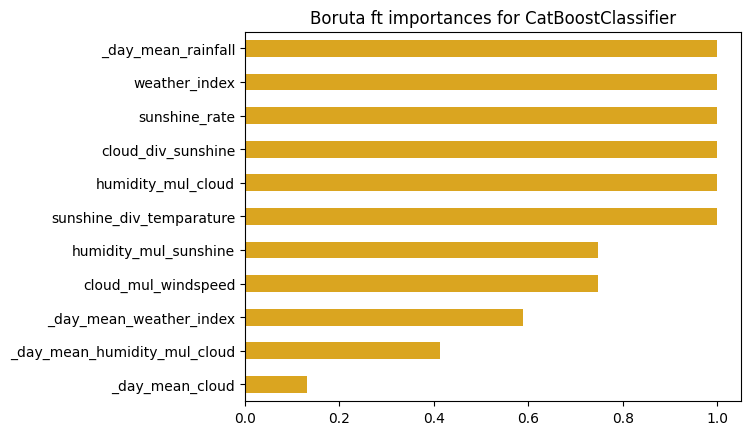

In [10]:
estimator = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=4,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.99)
catboost = model = estimator.fit(X, y)

__submission__

In [ ]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{uuid.uuid4().hex}.csv', index=False)

In [153]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{uuid.uuid4().hex}.csv', index=False)

In [ ]:
# base
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{uuid.uuid4().hex}.csv', index=False)

__NN approach__

In [12]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [13]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )
        # return (
        #     torch.as_tensor(self.x[index], dtype=torch.float32),
        #     torch.as_tensor(self.y[index], dtype=torch.float32)
        # )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 75])

In [40]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            # torch.nn.Conv1d(days, CHANNELS, kernel_size=2),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # second conv
            torch.nn.Conv1d(CHANNELS, 1, kernel_size=2),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            torch.nn.Flatten(1),
            # linears
            torch.nn.Linear(((features - days + 1) // 2 - 1) // 2, linear_channels),
            # torch.nn.Linear(((features - 1) // 2 - 1) // 2, linear_channels),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

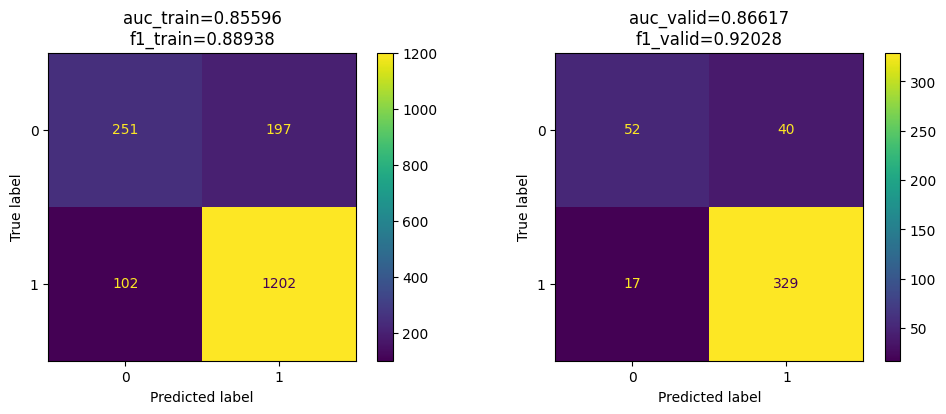

In [50]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    # hidden_channels=2,
    linear_channels=48,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=25, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [51]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.87808; TRAIN f1=0.90661 | VALID ROC AUC=0.87932; VALID f1=0.91393
Fold: 1; TRAIN ROC AUC=0.87775; TRAIN f1=0.90798 | VALID ROC AUC=0.83051; VALID f1=0.88889
Fold: 2; TRAIN ROC AUC=0.88201; TRAIN f1=0.90156 | VALID ROC AUC=0.86083; VALID f1=0.90283
Fold: 3; TRAIN ROC AUC=0.87594; TRAIN f1=0.90003 | VALID ROC AUC=0.86446; VALID f1=0.89712
Fold: 4; TRAIN ROC AUC=0.87798; TRAIN f1=0.90753 | VALID ROC AUC=0.86672; VALID f1=0.88843
Fold: 5; TRAIN ROC AUC=0.87891; TRAIN f1=0.90375 | VALID ROC AUC=0.86143; VALID f1=0.91057
Fold: 6; TRAIN ROC AUC=0.88044; TRAIN f1=0.90717 | VALID ROC AUC=0.85438; VALID f1=0.89837
MEAN: TRAIN ROC AUC=0.87873; TRAIN f1=0.90495 | VALID ROC AUC=0.85966; VALID f1=0.90002


__final fit__

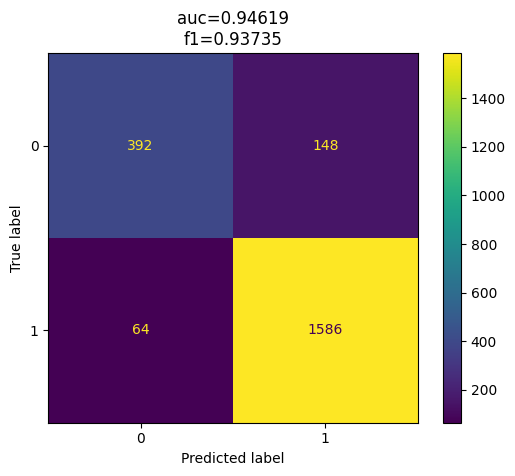

In [53]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    # hidden_channels=2,
    criterion=torch.nn.BCELoss(),
    lr=0.05,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [455]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = model.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

782c3172d778466f8c4000e2499be9ad


__mix predictions__

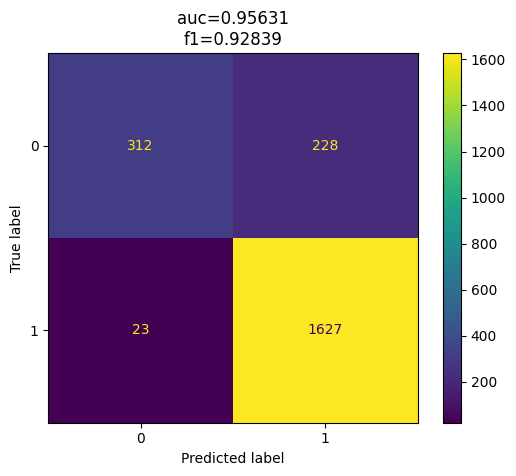

In [54]:
weights = np.array([0.4, 0.4, 0.2]).reshape(3, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0]
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [56]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

fea2f6cbe778477db386bf9ca82a30f7


In [ ]:
#